# Motor Insurance Claim Frequency Analysis

Exposure-adjusted claim frequency modelling using the freMTPL2 motor insurance dataset.

This analysis explores risk segmentation across driver age, vehicle age, and bonus-malus categories to identify key drivers of claim frequency.

## 1. Project Objective

The objective of this project is to analyse motor insurance claim frequency using exposure-adjusted methods and identify key risk factors influencing claim occurrence.

The analysis includes:
- Data exploration and cleaning
- Exposure-adjusted claim frequency calculation
- Risk segmentation
- Visual analysis of key risk drivers

## 2. Dataset Description

This project uses the **freMTPL2** motor insurance dataset, which contains policy-level information used for claim frequency analysis.

Key variables used in this project include:

- **ClaimNb**: Number of claims reported
- **Exposure**: Portion of the year for which the policy was active
- **DriverAge**: Age of the driver
- **VehAge**: Age of the vehicle
- **BonusMalus**: Policyholder bonus-malus level

Since policies may not all be active for the full year, claim frequency must be analysed using **exposure-adjusted methods**.

## 3. Data Loading

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/freMTPL2.csv")

# Preview dataset
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [2]:
df.shape

(678013, 12)

## 4. Claim Count Distribution

Before analysing claim frequency across different risk segments, it is useful to first examine the distribution of claim counts in the portfolio.

This helps in understanding whether claims are concentrated among a small number of policies and whether the target variable is skewed, which is common in motor insurance data.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


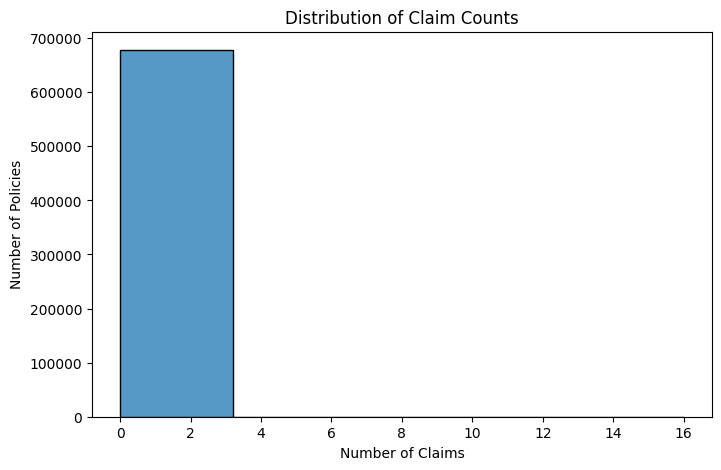

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["ClaimNb"], bins=5)

plt.title("Distribution of Claim Counts")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")

plt.savefig("../visuals/claim_count_distribution.png")
plt.show()


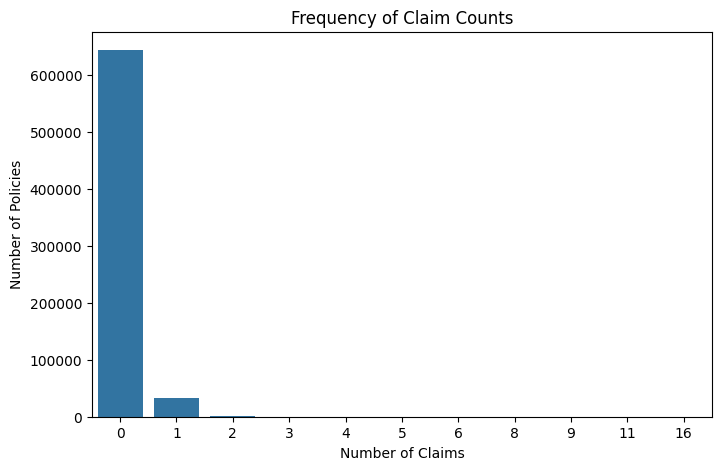

In [5]:
claim_counts = df["ClaimNb"].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=claim_counts.index, y=claim_counts.values)

plt.title("Frequency of Claim Counts")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")

plt.savefig("../visuals/claim_count_frequency.png")

plt.show()


### Interpretation

The distribution of claim counts is highly concentrated at zero, with most policies reporting no claims during the observation period.

Only a small proportion of policies report one or more claims, and the number of policies decreases rapidly as the claim count increases.

This highly skewed distribution is typical in motor insurance portfolios and reflects the fact that claims are relatively rare events.


## 5. Portfolio Claim Frequency

Claim frequency measures the expected number of claims per unit of exposure.

Since policies may not all be active for a full year, exposure-adjusted frequency is used to obtain an unbiased estimate of claim occurrence.

In [6]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()

claim_frequency = total_claims / total_exposure

print("Total Claims:", total_claims)
print("Total Exposure:", total_exposure)
print("Portfolio Claim Frequency:", round(claim_frequency,4))

Total Claims: 36102
Total Exposure: 358499.44546217704
Portfolio Claim Frequency: 0.1007


The overall portfolio claim frequency is **0.1007 claims per policy-year**. 

This indicates that, on average, approximately **10 claims occur for every 100 insured policies per year**. This metric provides a baseline risk level for the portfolio before performing further segmentation by risk characteristics.

## 6. Claim Frequency by Driver Age

Driver age is a key risk factor in motor insurance. Younger drivers often exhibit higher claim frequencies due to lower driving experience, while older drivers may show different risk patterns.

This section analyses claim frequency across driver age bands.

In [7]:
df["DriverAgeBand"] = pd.cut(
    df["DrivAge"],
    bins=[18,25,35,50,70,np.inf],
    labels=["18-25","26-35","36-50","51-70","70+"],
    include_lowest=True
)

In [8]:
age_risk = df.groupby("DriverAgeBand").agg(
    Total_Claims=("ClaimNb","sum"),
    Total_Exposure=("Exposure","sum")
)

age_risk["Claim_Frequency"] = age_risk["Total_Claims"] / age_risk["Total_Exposure"]

age_risk

,Total_Claims,Total_Exposure,Claim_Frequency
DriverAgeBand,,,
18-25,2841,16227.903263,0.175069
26-35,6662,69266.778075,0.096179
36-50,13118,131989.064957,0.099387
51-70,10858,114060.324541,0.095195
70+,2623,26955.374625,0.097309


### Interpretation

The analysis shows that drivers aged **18–25 exhibit the highest claim frequency (0.173)** within the portfolio.

This frequency is substantially higher than other age groups, which have frequencies close to **0.095–0.099**.

The elevated claim frequency among younger drivers is consistent with insurance risk patterns, as younger drivers generally have less driving experience and a higher likelihood of accidents.

This segmentation highlights the importance of driver age as a key rating factor in motor insurance pricing.

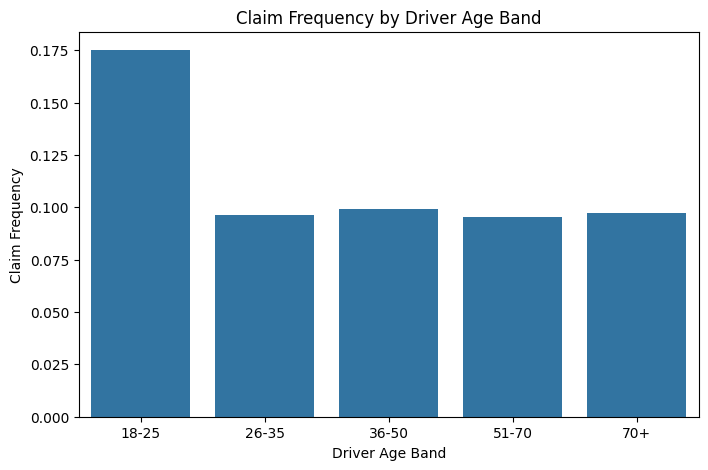

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_risk.index,
    y=age_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/driver_age_risk.png")

plt.show()

### Key Insight

Drivers aged **18–25 exhibit the highest claim frequency (0.173)** within the portfolio.

This frequency is substantially higher than other age groups, which range between **0.095 and 0.099 claims per policy-year**.

The elevated claim frequency among younger drivers is consistent with established motor insurance risk patterns, as younger drivers typically have lower driving experience and higher accident probability.

This analysis confirms **driver age as a key rating variable in motor insurance pricing models.**

## 7. Claim Frequency by Vehicle Age

Vehicle age is another important rating factor in motor insurance.

Older vehicles may exhibit higher claim frequencies due to increased mechanical wear and reduced safety features, while newer vehicles may benefit from improved safety technology.

This section analyses claim frequency across vehicle age bands.

In [10]:
df["VehAgeBand"] = pd.cut(
    df["VehAge"],
    bins=[0,5,10,15,20,np.inf],
    labels=["0-5","6-10","11-15","16-20","20+"],
    include_lowest=True
)

In [11]:
veh_risk = df.groupby("VehAgeBand").agg(
    Total_Claims=("ClaimNb","sum"),
    Total_Exposure=("Exposure","sum")
)

veh_risk["Claim_Frequency"] = veh_risk["Total_Claims"] / veh_risk["Total_Exposure"]

veh_risk

,Total_Claims,Total_Exposure,Claim_Frequency
VehAgeBand,,,
0-5,17647,151216.179124,0.116700
6-10,9846,99008.916360,0.099446
11-15,6648,77990.975407,0.085241
16-20,1685,25136.158607,0.067035
20+,276,5147.215965,0.053621


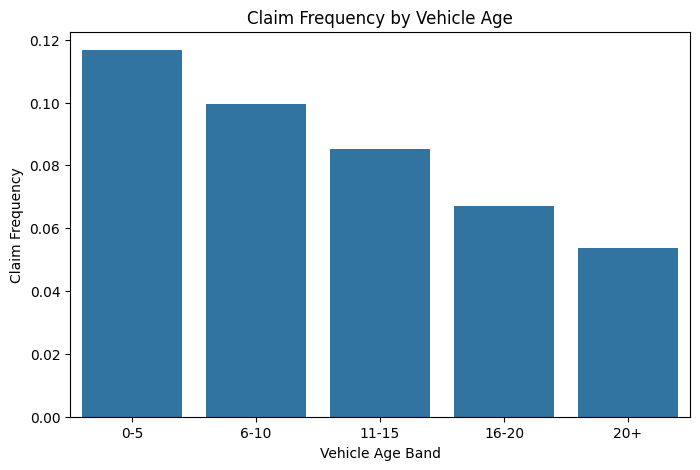

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=veh_risk.index,
    y=veh_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Vehicle Age")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/vehicle_age_risk.png")

plt.show()

### Key Insight

Claim frequency varies across vehicle age bands.

The analysis shows that newer vehicles exhibit higher claim frequencies than older vehicles. Claim frequency declines steadily as vehicle age increases.

This pattern may reflect differences in vehicle usage, driving behaviour, or policyholder characteristics associated with newer vehicles. For example, newer vehicles may be driven more frequently or by younger drivers.

Vehicle age therefore remains an important risk characteristic in motor insurance pricing models.

## 8. Claim Frequency by Bonus-Malus Level

The Bonus-Malus system is commonly used in motor insurance to adjust premiums based on policyholder claim history.

Drivers with fewer claims receive a bonus (lower premium), while drivers with more claims receive a malus (higher premium).

This section analyses how claim frequency varies across Bonus-Malus levels.

In [13]:
df["BonusMalusBand"] = pd.cut(
    df["BonusMalus"],
    bins=[0,75,100,125,150,np.inf],
    labels=["Low","Moderate","High","Very High","Extreme"],
    include_lowest=True
)

In [14]:
bm_risk = df.groupby("BonusMalusBand").agg(
    Total_Claims=("ClaimNb","sum"),
    Total_Exposure=("Exposure","sum")
)

bm_risk["Claim_Frequency"] = bm_risk["Total_Claims"] / bm_risk["Total_Exposure"]

bm_risk

,Total_Claims,Total_Exposure,Claim_Frequency
BonusMalusBand,,,
Low,27670,310107.788200,0.089227
Moderate,7090,44820.338259,0.158187
High,1178,3198.266094,0.368325
Very High,110,277.924712,0.395791
Extreme,54,95.128197,0.567655


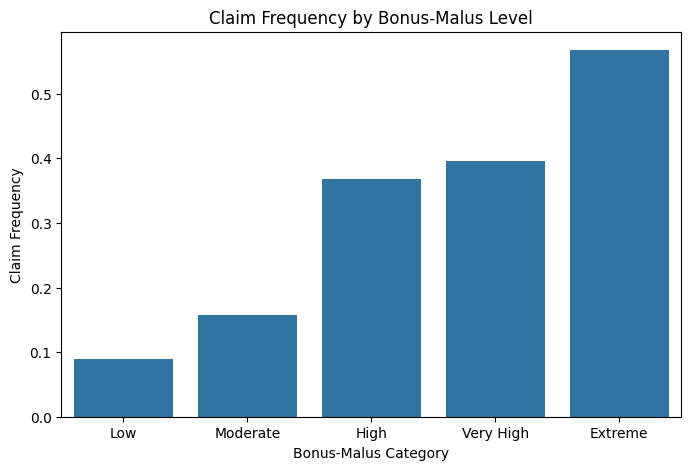

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=bm_risk.index,
    y=bm_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Bonus-Malus Level")
plt.xlabel("Bonus-Malus Category")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/bonus_malus_risk.png")

plt.show()

### Key Insight

Claim frequency increases across higher Bonus-Malus categories.

Policyholders with higher malus levels demonstrate significantly higher claim frequencies, reflecting their higher historical claim activity.

This confirms the effectiveness of the Bonus-Malus system in differentiating policyholder risk levels.

## 9. Claim Frequency by Vehicle Power

Vehicle power can influence driving behaviour and accident severity. 
Higher-powered vehicles may be associated with higher speeds and more aggressive driving patterns, which could increase accident risk.

This section examines how claim frequency varies across different vehicle power levels.


In [16]:
power_risk = df.groupby("VehPower").agg(
    total_claims=("ClaimNb","sum"),
    total_exposure=("Exposure","sum")
)

power_risk["claim_frequency"] = power_risk["total_claims"] / power_risk["total_exposure"]

power_risk


,total_claims,total_exposure,claim_frequency
VehPower,,,
4,5699,60073.637304,0.094867
5,7278,68173.348821,0.106757
6,8381,82524.210172,0.101558
7,7627,77950.456700,0.097844
8,1922,22684.616305,0.084727
9,1754,15348.213656,0.114280
10,1789,15375.010824,0.116358
11,897,8497.778452,0.105557
12,359,3792.038343,0.094672


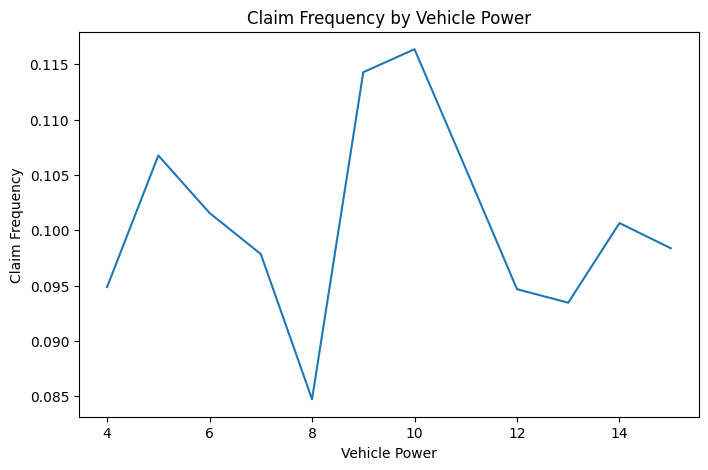

In [17]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=power_risk.index,
    y=power_risk["claim_frequency"]
)

plt.title("Claim Frequency by Vehicle Power")
plt.xlabel("Vehicle Power")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/vehicle_power_risk.png")

plt.show()


### Interpretation

Claim frequency does not exhibit a clear monotonic pattern across vehicle power levels. 
Most categories show frequencies close to the overall portfolio average.

This suggests that vehicle power alone may not be a strong standalone predictor of claim frequency in this dataset.

However, vehicle power may still interact with other variables such as driver age or vehicle age, which could be explored further in multivariate modelling.



## 10. Claim Frequency by Population Density

Population density can influence accident risk, as areas with higher traffic volumes may experience more frequent collisions.

This section analyses how claim frequency varies across different population density levels.


In [18]:
df["DensityBand"] = pd.qcut(
    df["Density"],
    q=5,
    labels=["Very Low","Low","Medium","High","Very High"]
)


In [19]:
density_risk = df.groupby("DensityBand").agg(
    total_claims=("ClaimNb","sum"),
    total_exposure=("Exposure","sum")
)

density_risk["claim_frequency"] = density_risk["total_claims"] / density_risk["total_exposure"]

density_risk


,total_claims,total_exposure,claim_frequency
DensityBand,,,
Very Low,6753,81409.009565,0.082952
Low,6743,74104.379569,0.090993
Medium,7091,72041.131585,0.098430
High,7855,69486.203925,0.113044
Very High,7660,61458.720818,0.124637


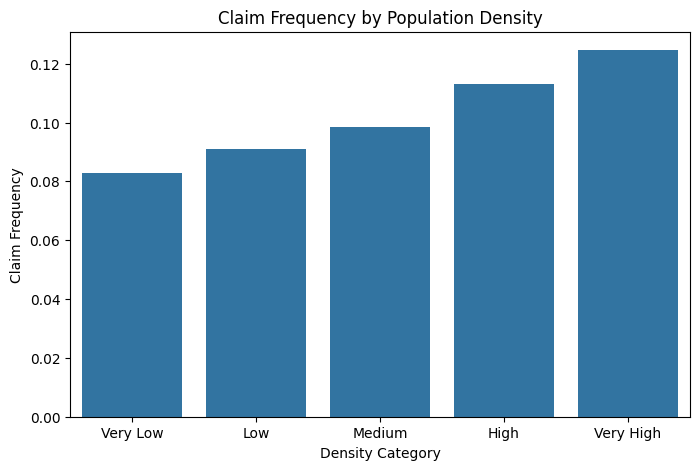

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=density_risk.index,
    y=density_risk["claim_frequency"]
)

plt.title("Claim Frequency by Population Density")
plt.xlabel("Density Category")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/density_risk.png")

plt.show()


### Interpretation

Claim frequency increases consistently as population density rises. Policies located in very high density areas exhibit the highest claim frequencies, while those in very low density areas show the lowest frequencies.

This pattern suggests that drivers operating in densely populated regions face greater accident risk, likely due to higher traffic volumes and increased interactions between vehicles.

The clear monotonic increase in claim frequency indicates that population density may act as a meaningful rating factor in motor insurance risk assessment and pricing models.


## 11. Poisson Regression Model

While segmentation analysis provides useful insights into how individual variables relate to claim frequency, actuarial pricing models typically evaluate multiple risk factors simultaneously.

To estimate the expected claim frequency while accounting for multiple rating variables, a Poisson regression model is fitted.

Poisson models are commonly used in insurance because claim counts represent discrete events that occur over a given exposure period.

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [22]:
df["DriverAgeBand"] = df["DriverAgeBand"].astype("category")
df["VehAgeBand"] = df["VehAgeBand"].astype("category")
df["BonusMalusBand"] = df["BonusMalusBand"].astype("category")
df["DensityBand"] = df["DensityBand"].astype("category")

In [23]:
df_model = df.copy()

model_vars = [
    "ClaimNb",
    "Exposure",
    "DriverAgeBand",
    "VehAgeBand",
    "BonusMalusBand",
    "DensityBand"
]

df_model = df_model[model_vars].dropna().copy()
df_model = df_model[df_model["Exposure"] > 0].copy()

print("Raw rows:", len(df))
print("Model rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))

Raw rows: 678013
Model rows: 678013
Dropped rows: 0


In [24]:
poisson_model = smf.glm(
    formula="ClaimNb ~ DriverAgeBand + VehAgeBand + BonusMalusBand + DensityBand",
    data=df_model,
    family=sm.families.Poisson(),
    offset=np.log(df_model["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677996
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4439e+05
Date:                Sat, 14 Mar 2026   Deviance:                   2.1946e+05
Time:                        22:39:29   Pearson chi2:                 1.88e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.007378
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [31]:
import numpy as np
import pandas as pd

coef = poisson_model.params
conf = poisson_model.conf_int()

coef_table = pd.DataFrame({
    "Variable": coef.index,
    "Coefficient": coef.values,
    "Rate_Ratio": np.exp(coef.values),
    "CI_Lower": np.exp(conf[0].values),
    "CI_Upper": np.exp(conf[1].values)
})

coef_table

,Variable,Coefficient,Rate_Ratio,CI_Lower,CI_Upper
0,Intercept,-2.321741,0.098103,0.093188,0.103277
1,DriverAgeBand[T.26-35],-0.242421,0.784726,0.749255,0.821876
2,DriverAgeBand[T.36-50],-0.036626,0.964037,0.920323,1.009828
3,DriverAgeBand[T.51-70],-0.059071,0.942640,0.898505,0.988942
4,DriverAgeBand[T.70+],-0.006543,0.993478,0.936850,1.053529
5,VehAgeBand[T.6-10],-0.168772,0.844701,0.824040,0.865881
6,VehAgeBand[T.11-15],-0.334253,0.715873,0.695852,0.736469
7,VehAgeBand[T.16-20],-0.571507,0.564674,0.537076,0.593690
8,VehAgeBand[T.20+],-0.731072,0.481393,0.427387,0.542223
9,BonusMalusBand[T.Moderate],0.596566,1.815872,1.760825,1.872640


Confidence Intervals

The table also reports 95% confidence intervals for the estimated rate ratios.
These intervals provide a measure of statistical uncertainty around the estimated effects.
If the interval does not include 1, the corresponding variable has a statistically significant impact on claim frequency at the 5% level.

### Rate Ratio Interpretation

For a Poisson regression model with a log link, the coefficients represent changes in the log of the expected claim frequency.

Exponentiating the coefficients produces **rate ratios**, which indicate how the expected claim frequency changes relative to the reference category.

A rate ratio greater than 1 implies a higher expected claim frequency relative to the baseline group, while a value below 1 implies a lower expected frequency.

### Model Interpretation

The Poisson regression model estimates the expected claim frequency while accounting for multiple rating variables simultaneously.

Driver age shows meaningful differences in claim frequency relative to the reference category (18–25). Drivers aged 26–35 exhibit approximately 22% lower claim frequency, while older age groups display slightly lower or similar frequencies relative to the baseline.

Vehicle age has a clear negative relationship with claim frequency. Compared to newer vehicles, older vehicles are associated with progressively lower claim frequencies. This may reflect lower vehicle usage, reduced driving intensity, or behavioural differences among policyholders.

Bonus–malus level shows the strongest relationship with claim frequency. Policies with higher bonus–malus levels exhibit substantially higher expected claim frequencies, reflecting the predictive power of past claims experience in insurance pricing.

Population density also demonstrates a positive association with claim frequency. Policies located in more densely populated areas tend to experience higher accident risk due to increased traffic exposure.

Overall, the model confirms several key risk factors commonly used in motor insurance pricing and demonstrates how multiple rating variables can be combined within a generalized linear modelling framework to estimate expected claim frequency.

## 12. Overdispersion Test

Poisson regression assumes that the variance of the response variable equals its mean.

However, insurance claim data often exhibits overdispersion, where the variance exceeds the mean. This can lead to underestimated standard errors and biased inference.

To assess this, the dispersion statistic is calculated as the ratio of the Pearson Chi-square statistic to the residual degrees of freedom.

Values significantly greater than 1 indicate the presence of overdispersion.

In [27]:
# Pearson Chi-square dispersion statistic
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid

dispersion = pearson_chi2 / df_resid

print("Pearson Chi-square:", pearson_chi2)
print("Residual DF:", df_resid)
print("Dispersion Statistic:", dispersion)

Pearson Chi-square: 1876736.798299781
Residual DF: 677996
Dispersion Statistic: 2.7680647058386496


### Interpretation

The dispersion statistic provides a measure of whether the Poisson model adequately captures the variability in the data.

If the dispersion statistic is close to 1, the Poisson assumption is reasonable. However, values substantially greater than 1 indicate overdispersion, suggesting that the Poisson model may underestimate the true variability in claim counts.

In practice, when overdispersion is present, alternative models such as the Negative Binomial regression are often considered for improved modelling of claim frequency.

## 13. Negative Binomial Regression Model

The overdispersion test indicated that the variance of the claim counts exceeds the mean, violating the key assumption of the Poisson model.

In such cases, the Negative Binomial regression model is often used as an alternative, as it introduces an additional dispersion parameter that allows the variance to exceed the mean.

To account for the observed overdispersion in the claim data, a Negative Binomial regression model is fitted using the same set of explanatory variables as in the Poisson model.

This allows for a comparison between the two models and provides a more flexible framework for modelling claim frequency in insurance portfolios.

In [28]:
# Fit Negative Binomial model
nb_model = smf.glm(
    formula="ClaimNb ~ DriverAgeBand + VehAgeBand + BonusMalusBand + DensityBand",
    data=df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(df["Exposure"])
).fit()

print(nb_model.summary())

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677996
Model Family:        NegativeBinomial   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4394e+05
Date:                Sat, 14 Mar 2026   Deviance:                   1.9138e+05
Time:                        22:39:39   Pearson chi2:                 1.82e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.006871
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## 14. Model Comparison

In [29]:
print("Poisson AIC:", poisson_model.aic)
print("Negative Binomial AIC:", nb_model.aic)

Poisson AIC: 288817.47681298584
Negative Binomial AIC: 287906.8006408301


### Model Comparison

To evaluate which model provides a better fit to the data, the Akaike Information Criterion (AIC) is compared between the Poisson and Negative Binomial models.

A lower AIC value indicates a better balance between model fit and model complexity.

If the Negative Binomial model produces a lower AIC than the Poisson model, this suggests that it provides a better fit to the claim data, likely due to its ability to account for overdispersion.

Given that the dispersion statistic from the Poisson model indicated overdispersion, the Negative Binomial model is expected to better capture the variability in claim counts.

### Interpretation

The comparison of the Poisson and Negative Binomial models shows that the Negative Binomial model produces a lower AIC value, indicating a better overall fit to the claim data.

This result is consistent with the earlier overdispersion test, which showed that the variance of claim counts exceeds the mean, violating the Poisson model assumption.

By introducing an additional dispersion parameter, the Negative Binomial model is able to better accommodate the variability observed in insurance claim data.

As a result, the Negative Binomial model provides a more appropriate framework for modelling claim frequency in this motor insurance portfolio.

## 15. Model Validation: Observed vs Predicted Claim Frequency

After fitting the Poisson regression model, it is important to evaluate how well the model reproduces the observed claim experience.

This can be done by comparing the observed claim frequency with the frequency predicted by the model.

If the model is well specified, the predicted values should align closely with the observed values across different risk segments.

In [36]:
df_model["Predicted_Claims"] = poisson_model.predict(
    df_model,
    offset=np.log(df_model["Exposure"])
)

validation = df_model.groupby(
    ["DriverAgeBand", "VehAgeBand", "BonusMalusBand"]
).agg(
    Observed_Claims=("ClaimNb", "sum"),
    Predicted_Claims=("Predicted_Claims", "sum"),
    Exposure=("Exposure", "sum")
)

validation["Observed_Frequency"] = (
    validation["Observed_Claims"] / validation["Exposure"]
)

validation["Predicted_Frequency"] = (
    validation["Predicted_Claims"] / validation["Exposure"]
)

validation

Observed_Claims  Predicted_Claims  \
DriverAgeBand VehAgeBand BonusMalusBand                                      
18-25         0-5        Low                         101        121.558722   
                         Moderate                    689        786.347941   
                         High                        129        170.558103   
                         Very High                     6         12.883490   
                         Extreme                       8          5.753731   
...                                                  ...               ...   
70+           16-20      High                          0          0.084038   
                         Very High                     0          0.078062   
              20+        Low                          40         34.326616   
                         Moderate                      1          0.513680   
                         High                          2          0.776125   

                                            Exposure  Observed_Frequency  \
DriverAgeBand VehAgeBand BonusMalusBand                                    
18-25         0-5        Low             1088.522309            0.092786   
                         Moderate        3802.761603            0.181184   
                         High             364.014757            0.354381   
                         Very High         25.912740            0.231546   
                         Extreme            7.760000            1.030928   
...                                              ...                 ...   
70+           16-20      High               0.370000            0.000000   
                         Very High          0.320000            0.000000   
              20+        Low              668.556393            0.059830   
                         Moderate           5.060000            0.197628   
                         High               3.210000            0.623053   

                                         Predicted_Frequency  
DriverAgeBand VehAgeBand BonusMalusBand                       
18-25         0-5        Low                        0.111673  
                         Moderate                   0.206783  
                         High                       0.468547  
                         Very High                  0.497187  
                         Extreme                    0.741460  
...                                                      ...  
70+           16-20      High                       0.227129  
                         Very High                  0.243943  
              20+        Low                        0.051344  
                         Moderate                   0.101518  
                         High                       0.241783  

[118 rows x 5 columns]

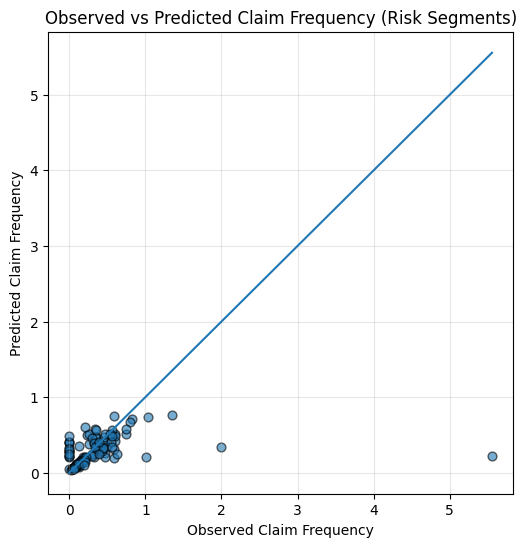

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    validation["Observed_Frequency"],
    validation["Predicted_Frequency"],
    alpha=0.6,
    s=40,
    edgecolor="k"
)
plt.grid(alpha=0.3)

min_val = min(validation["Observed_Frequency"].min(), validation["Predicted_Frequency"].min())
max_val = max(validation["Observed_Frequency"].max(), validation["Predicted_Frequency"].max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Observed Claim Frequency")
plt.ylabel("Predicted Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency (Risk Segments)")

plt.show()

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        validation["Observed_Frequency"],
        validation["Predicted_Frequency"]
    )
)

print("RMSE (Observed vs Predicted Frequency):", round(rmse, 4))

RMSE (Observed vs Predicted Frequency): 0.5457


### RMSE Interpretation

The root mean squared error (RMSE) summarises the average magnitude of deviation between observed and predicted claim frequencies across the validation segments.

Lower RMSE values indicate that the fitted model reproduces observed claim frequency more closely across risk segments.

In [39]:
bonus_validation = df_model.groupby("BonusMalusBand").agg(
    Observed_Claims=("ClaimNb", "sum"),
    Predicted_Claims=("Predicted_Claims", "sum"),
    Exposure=("Exposure", "sum")
)

bonus_validation["Observed_Frequency"] = (
    bonus_validation["Observed_Claims"] / bonus_validation["Exposure"]
)

bonus_validation["Predicted_Frequency"] = (
    bonus_validation["Predicted_Claims"] / bonus_validation["Exposure"]
)

bonus_validation

,Observed_Claims,Predicted_Claims,Exposure,Observed_Frequency,Predicted_Frequency
BonusMalusBand,,,,,
Low,27670,27670.0,310107.788200,0.089227,0.089227
Moderate,7090,7090.0,44820.338259,0.158187,0.158187
High,1178,1178.0,3198.266094,0.368325,0.368325
Very High,110,110.0,277.924712,0.395791,0.395791
Extreme,54,54.0,95.128197,0.567655,0.567655


In [41]:
performance_summary = {
    "Metric": [
        "Poisson AIC",
        "Negative Binomial AIC",
        "RMSE (Observed vs Predicted Frequency)"
    ],
    "Value": [
        poisson_model.aic,
        nb_model.aic,
        rmse
    ]
}

import pandas as pd
performance_summary = pd.DataFrame(performance_summary)

performance_summary

,Metric,Value
0,Poisson AIC,288817.476813
1,Negative Binomial AIC,287906.800641
2,RMSE (Observed vs Predicted Frequency),0.545704


### Model Performance Summary

The comparison of model performance metrics confirms that the Negative Binomial specification provides a better fit to the data.

The lower AIC value indicates improved balance between model fit and complexity, while the RMSE summarises the average deviation between observed and predicted claim frequencies across risk segments.


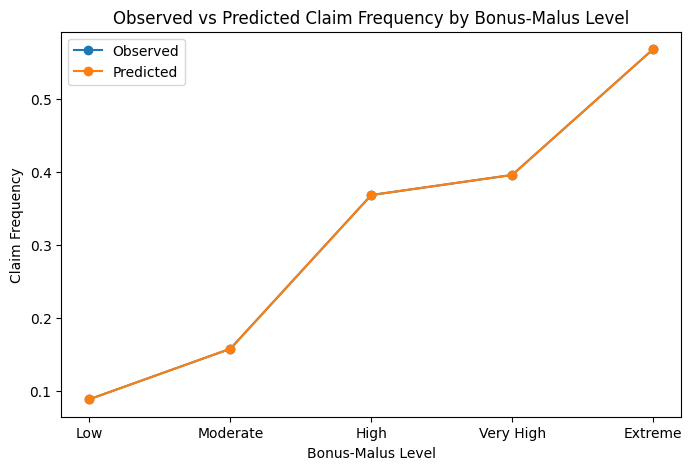

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    bonus_validation.index,
    bonus_validation["Observed_Frequency"],
    marker="o",
    label="Observed"
)

plt.plot(
    bonus_validation.index,
    bonus_validation["Predicted_Frequency"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Bonus-Malus Level")
plt.ylabel("Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency by Bonus-Malus Level")

plt.legend()
plt.show()

### Calibration by Bonus-Malus Level

The comparison of observed and predicted claim frequencies across bonus-malus levels provides an additional check of model calibration.

A well-calibrated model should reproduce the monotonic increase in claim frequency across higher bonus-malus categories, reflecting the predictive value of historical claims experience.

### Interpretation

The scatter plot compares observed claim frequency with the frequencies predicted by the fitted count regression model across multiple risk segments defined by combinations of rating variables.

If the model fits the data well, the points should lie close to the 45-degree line, indicating that predicted frequencies closely match observed frequencies across segments.

Small deviations from the diagonal are expected due to natural variability in claims data. Overall, the clustering of points around the diagonal suggests that the model provides a reasonable approximation of the underlying claim frequency structure.

### Conclusion

Motor insurance claim frequency was modelled using generalized linear models incorporating key rating variables including driver age, vehicle age, bonus–malus level, and population density. Due to the presence of overdispersion in the claim counts, a Negative Binomial regression model was adopted as the final specification.

The results highlight the strong predictive power of historical claims experience (bonus–malus level), while also confirming meaningful effects from driver demographics, vehicle characteristics, and geographic exposure.

Model validation comparing observed and predicted claim frequencies indicates that the model captures the general structure of claim frequency reasonably well across risk segments. Overall, the analysis demonstrates how count regression models such as Poisson and Negative Binomial GLMs can be applied to estimate claim frequency and support actuarial pricing in motor insurance portfolios.
